# Benchmarks Schwarzschild Black Hole (cartesian coordinates)

Running the code cells below will compute and automatically generate the following figures:

-  **From Section 5.2**:

    - **Figure 1(a)**, saved as **`Fig1.pdf`**
    - **Figure 1(b)**, saved as **`Fig2.pdf`**


- **From Section 3.1.1**

    - **Figure 3**, saved as **`Fig7.pdf`**
    - **Figure 4(a)**, saved as **`Fig8.pdf`**
    - **Figure 4(b)**, saved as **`Fig9.pdf`**
  

<ul id="top">
    <li><a href="#Loading-packages-and-functions">Loading packages and functions</a></li>
    <li><a href="#Initial-value-problem:-Schwarzschild-black-hole">Initial-value-problem:-Schwarzschild-black-hole</a></li> 
    <li><a href="#IRKGL16-integrations">IRKGL16 integrations</a></li>
    <ul>
        <li><a href="#Comparison-of-IRKGL-schemes">Comparison of IRKGL schemes</a></li>
    </ul>
    <li><a href="#Splitting-integrations">Splitting integrations</a></li>
    <li><a href="#Benchmarks-diagrams">Benchmarks diagrams</a></li>
    <ul>
        <li><a href="#Work-precison-diagrams">Work-precison diagrams</a></li>
        <li><a href="#Error-in-Energy">Error in Energy</a></li>
        <li><a href="#Error-in-Solution">Error in Solution</a></li>
    </ul>
</ul>

## Loading packages and functions

In [1]:
using LinearAlgebra
using Plots
using LaTeXStrings
#using IRKGaussLegendre

PATH_IRKGL="../../../../Clone_IRKGL_16_nov_2025/IRKGaussLegendre.jl/"
include(string(PATH_IRKGL,"src/IRKGaussLegendre.jl"))
using .IRKGaussLegendre  ## bertsio lokala exekutatzeko  


PATH_Splitting="../../"
include(string(PATH_Splitting,"/src/SplittingMethods.jl"))
using .SplittingMethods  ## bertsio lokala exekutatzeko  

include("../Aux_functions.jl")

PATH_ODES=string(PATH_Splitting,"ODEProblems/")
# Equations in polar coordinates (for IRKGL16 method)
include(string(PATH_ODES,"InitialSchwarzschild.jl"))
include(string(PATH_ODES,"SchwarzschildBH.jl"))
# # Equations in cartesian coordinates (for Splitting method)
include(string(PATH_ODES,"InitialSchwarzschildv2.jl"))
include(string(PATH_ODES,"SchwarzschildBHv2.jl"));

In [2]:
Base.@boundscheck false

false

##### <a href="#top">Back to the top</a>

## Initial value problem: Schwarzschild black-hole

In [3]:
u0, parms = InitialSchwarzschild()

t0=0.
tF=1e5  #1e4
tspan=(t0,tF);

<a href="#top">Back to the top</a>

## IRKGL16 integrations

### Comparison of IRKGL schemes

In [4]:
prob = ODEProblem{true,SciMLBase.FullSpecialize}(SchwarzschildODE!, u0, tspan , parms)

HAM=Ham_Schwarzschild
@show(HAM(u0,parms));

HAM(u0, parms) = -0.5


In [5]:
ddt0_irk16=collect(10.:2:30)
nruns=100

alg=IRKGL16(simd=true, seq=false)
sols_irk16_simd=run_many_IRKGL16(alg, prob, ddt0_irk16, HAM, nruns=nruns)
#fig=plots_IRKGL16("IRKGL16_SIMD",prob,HAM,sols_irk16_simd)
#display(fig)
#
alg=IRKGL16(simd=false, seq=true)
sols_irk16_seq=run_many_IRKGL16(alg,prob,ddt0_irk16,HAM, nruns=nruns)
#fig=plots_IRKGL16("IRKGL16_SEQ",prob,HAM,sols_irk16_seq)
#display(fig)
#
alg=IRKGL16(simd=true, seq=true)
sols_irk16_hyb=run_many_IRKGL16(alg,prob,ddt0_irk16,HAM, nruns=nruns);
#fig=plots_IRKGL16("IRKGL16_HYB",prob,HAM,sols_irk16_hyb)
#display(fig)

,10.0,12.0,14.0,16.0,18.0,20.0,22.0,24.0,26.0,28.0,30.0,10.0,12.0,14.0,16.0,18.0,20.0,22.0,24.0,26.0,28.0,30.0,10.0,12.0,14.0,16.0,18.0,20.0,22.0,24.0,26.0,28.0,30.0

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


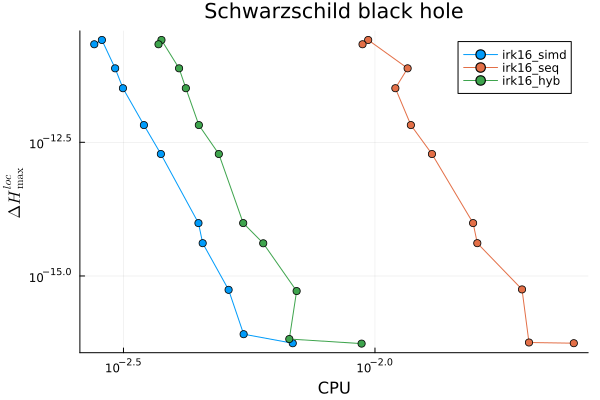

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


In [6]:
#
sols2plot=[sols_irk16_simd, sols_irk16_seq, sols_irk16_hyb]
labels2plot=["IRKGL16-SIMD", "IRKGL16-SEQ", "IRKGL16-HYBR"]

pl_=plot(title="Schwarzschild black hole", xlabel="CPU", ylabel=L"\Delta H^{loc}_{\mathrm{max}}",
          scale=:log10)

for i in 1:length(sols2plot)
    sols=sols2plot[i]
    plot!(pl_, sols.cpus , sols.MaxΔHlocal, markershape=:circle, label=labels2plot[i])
end
display(pl_)

In [7]:
#[sols_irk16_simd.dts sols_irk16_simd.retcodes sols_irk16_simd.iters sols_irk16_simd.cpus sols_irk16_simd.MaxΔHlocal]

In [8]:
#[sols_irk16_seq.dts sols_irk16_seq.retcodes sols_irk16_seq.iters sols_irk16_seq.cpus sols_irk16_seq.MaxΔHlocal]

In [9]:
#[sols_irk16_hyb.dts sols_irk16_hyb.retcodes sols_irk16_hyb.iters sols_irk16_hyb.cpus sols_irk16_hyb.MaxΔHlocal]

In [10]:
#log(sols_irk16_simd.MaxΔHlocal[4]/sols_irk16_simd.MaxΔHlocal[8])/log(sols_irk16_simd.cpus[8]/sols_irk16_simd.cpus[4])

In [11]:
#log(sols_irk16_simd.MaxΔHlocal[4]/sols_irk16_simd.MaxΔHlocal[8])/log(ddt0_irk16[4]/ddt0_irk16[8])

###  IRKGL12 integrations (s=6)

In [12]:
ddt0_irk12=ddt0_irk16*3/4 
steps_irk12=tF./ddt0_irk12
nruns=100

alg=IRKGL16(s=6,simd=true, seq=false)
sols_irk12_simd=run_many_IRKGL16(alg, prob, ddt0_irk12, HAM, nruns=nruns)
#fig=plots_IRKGL16("IRKGL12_SIMD",prob,HAM,sols_irk12_simd)
#display(fig)
#
alg=IRKGL16(s=6,simd=false, seq=true)
sols_irk12_seq=run_many_IRKGL16(alg,prob,ddt0_irk12,HAM, nruns=nruns)
#fig=plots_IRKGL16("IRKGL12_SEQ",prob,HAM,sols_irk12_seq)
#display(fig)
#
alg=IRKGL16(s=6,simd=true, seq=true)
sols_irk12_hyb=run_many_IRKGL16(alg,prob,ddt0_irk16,HAM, nruns=nruns);
#fig=plots_IRKGL16("IRKGL12_HYB",prob,HAM,sols_irk12_hyb)
#display(fig)

,7.5,9.0,10.5,12.0,13.5,15.0,16.5,18.0,19.5,21.0,22.5,7.5,9.0,10.5,12.0,13.5,15.0,16.5,18.0,19.5,21.0,22.5,10.0,12.0,14.0,16.0,18.0,20.0,22.0,24.0,26.0,28.0,30.0

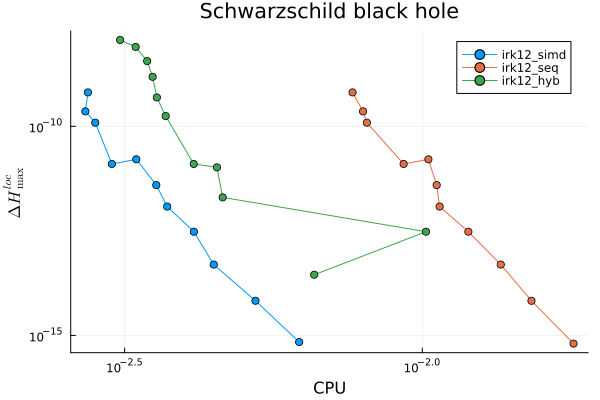

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


In [13]:
#--
sols2plot=[sols_irk12_simd, sols_irk12_seq, sols_irk12_hyb]
labels2plot=["IRKGL12-SIMD", "IRKGL12-SEQ", "IRKGL12-HYBR"]

pl_=plot(title="Schwarzschild black hole", xlabel="CPU", ylabel=L"\Delta H^{loc}_{\mathrm{max}}",
          scale=:log10)

for i in 1:length(sols2plot)
    sols=sols2plot[i]
    plot!(pl_, sols.cpus , sols.MaxΔHlocal, markershape=:circle, label=labels2plot[i])
end
display(pl_)

### IRKGL8 integrations (s=4)

In [14]:
ddt0_irk8=ddt0_irk16/2 
steps_irk8=tF./ddt0_irk8
nruns=100

alg=IRKGL16(s=4,simd=true, seq=false)
sols_irk8_simd=run_many_IRKGL16(alg, prob, ddt0_irk8, HAM, nruns=nruns)
#fig=plots_IRKGL16("IRKGL8_SIMD",prob,HAM,sols_irk8_simd)
#display(fig)
#
alg=IRKGL16(s=4,simd=false, seq=true)
sols_irk8_seq=run_many_IRKGL16(alg,prob,ddt0_irk8,HAM, nruns=nruns)
#fig=plots_IRKGL16("IRKGL8_SEQ",prob,HAM,sols_irk8_seq)
#display(fig)
#
alg=IRKGL16(s=4,simd=true, seq=true)
sols_irk8_hyb=run_many_IRKGL16(alg,prob,ddt0_irk16,HAM, nruns=nruns);
#fig=plots_IRKGL16("IRKGL8_HYB",prob,HAM,sols_irk8_hyb)
#display(fig)

,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,10.0,12.0,14.0,16.0,18.0,20.0,22.0,24.0,26.0,28.0,30.0

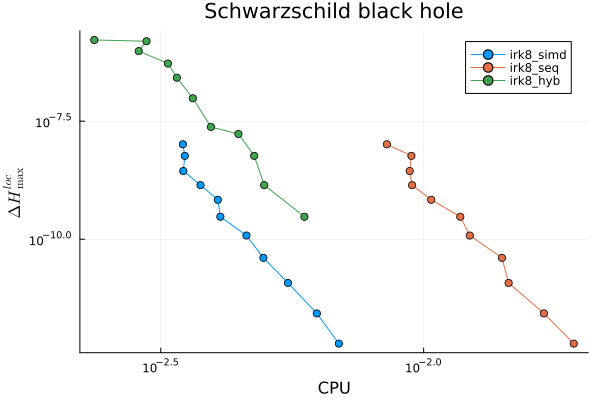

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


In [15]:
#
sols2plot=[sols_irk8_simd, sols_irk8_seq, sols_irk8_hyb]
labels2plot=["IRKGL8-SIMD", "IRKGL8-SEQ", "IRKGL8-HYBR"]

pl_=plot(title="Schwarzschild black hole", xlabel="CPU", ylabel=L"\Delta H^{loc}_{\mathrm{max}}",
          scale=:log10)

for i in 1:length(sols2plot)
    sols=sols2plot[i]
    plot!(pl_, sols.cpus , sols.MaxΔHlocal, markershape=:circle, label=labels2plot[i])
end
display(pl_)

### IRKGL4 integrations (s=2)

In [16]:
ddt0_irk4=ddt0_irk16/4 
steps_irk4=tF./ddt0_irk4
nruns=100

alg=IRKGL16(s=2,simd=true, seq=false)
sols_irk4_simd=run_many_IRKGL16(alg, prob, ddt0_irk4, HAM, nruns=nruns)
#fig=plots_IRKGL16("IRKGL4_SIMD",prob,HAM,sols_irk4_simd)
#display(fig)
#
alg=IRKGL16(s=2,simd=false, seq=true)
sols_irk4_seq=run_many_IRKGL16(alg,prob,ddt0_irk4,HAM, nruns=nruns)
#fig=plots_IRKGL16("IRKGL4_SEQ",prob,HAM,sols_irk4_seq)
#display(fig)
#
alg=IRKGL16(s=2,simd=true, seq=true)
sols_irk4_hyb=run_many_IRKGL16(alg,prob,ddt0_irk16,HAM, nruns=nruns);
#fig=plots_IRKGL16("IRKGL4_HYB",prob,HAM,sols_irk4_hyb)
#display(fig)

,2.5,3.0,3.5,4.0,4.5,5.0,5.5,6.0,6.5,7.0,7.5,2.5,3.0,3.5,4.0,4.5,5.0,5.5,6.0,6.5,7.0,7.5,10.0,12.0,14.0,16.0,18.0,20.0,22.0,24.0,26.0,28.0,30.0

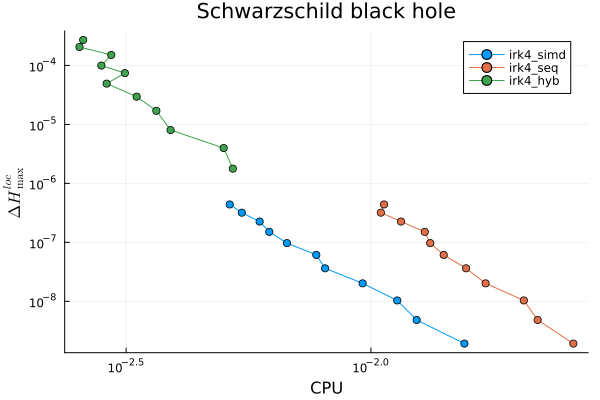

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


In [17]:
#
sols2plot=[sols_irk4_simd, sols_irk4_seq, sols_irk4_hyb]
labels2plot=["IRKGL4-SIMD", "IRKGL4-SEQ", "IRKGL4-HYBR"]

pl_=plot(title="Schwarzschild black hole", xlabel="CPU", ylabel=L"\Delta H^{loc}_{\mathrm{max}}",
          scale=:log10)

for i in 1:length(sols2plot)
    sols=sols2plot[i]
    plot!(pl_, sols.cpus , sols.MaxΔHlocal, markershape=:circle, label=labels2plot[i])
end
display(pl_)

### Diagrams

In [18]:
sols2plot=[sols_irk16_simd, sols_irk16_seq,
           sols_irk12_simd, sols_irk12_seq,
           sols_irk8_simd, sols_irk8_seq,
           sols_irk4_simd, sols_irk4_seq
           ]

labels2plot=["IRKGL16-SIMD", "IRKGL16-SEQ", 
             "IRKGL12-SIMD", "IRKGL12-SEQ",
             "IRKGL8-SIMD", "IRKGL8-SEQ",
             "IRKGL4-SIMD", "IRKGL4-SEQ"
]

labels2plot_=["IRKGL16", "IRKGL16", 
             "IRKGL12", "IRKGL12",
             "IRKGL8", "IRKGL8",
             "IRKGL4", "IRKGL4"
]

markershape2plot=[:circle, :xcross, :circle, :xcross, 
                  :circle, :xcross, :circle, :xcross]


ls2plot=[:solid, :solid, :solid, :solid, 
         :solid, :solid, :solid, :solid]

#colors2plot = [:red, :blue, :green, :orange, :purple, :cyan, :magenta, :teal, :gold]
colors2plot = [:red, :red, :blue, :blue, 
               :green, :green, :orange, :orange]

stages = [8,8,6,6,4,4,2,2];

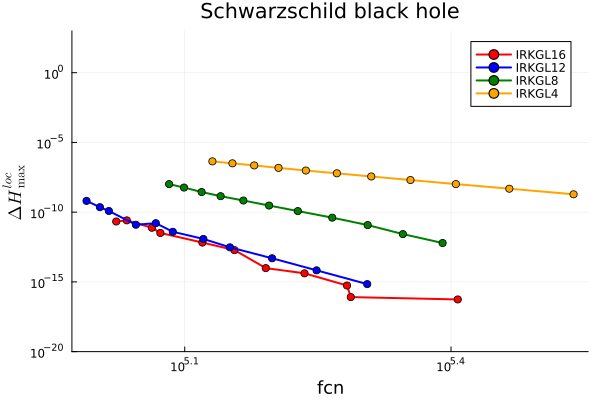

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


In [19]:
yrange=(1e-20, 1e3)
xrange=(1,50)


pl3=plot(scale=:log10,
         ylimits=yrange,    
         title="Schwarzschild black hole", 
         xlabel="fcn", ylabel=L"\Delta H^{loc}_{\mathrm{max}}",
         legend=:topright,
         guidefont=font(12), labelsize=10)

for i in 1:2:length(sols2plot)
       
    sols=sols2plot[i]
    fcn=stages[i]*(sols.iters)
    plot!(pl3, fcn , sols.MaxΔHlocal,
          markershape=:circle, lw=2,
          label=labels2plot_[i], color=colors2plot[i])
end

display(pl3)

In [20]:
savefig("./figures/Fig1.pdf")

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


"/home/mikel/Nextcloud/Gure taldea (Ehu box)/IRKGL-2025/6-Splitting-metodoak/Splitting Solvers Implementation/Experiments_Article3/5_3_1-Atala/figures/Fig1.pdf"

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


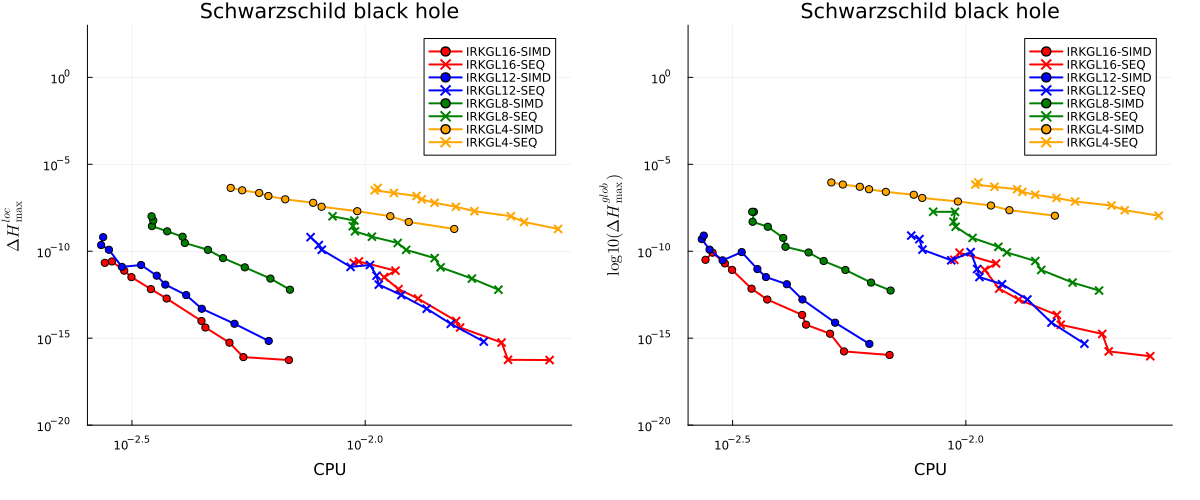

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict

In [21]:
yrange=(1e-20, 1e3)

xrange=(1,50)

sols=sols_irk16_simd
pl1=plot( sols.cpus , sols.MaxΔHlocal, scale=:log10,
          markershape=markershape2plot[1], lw=2, ls=ls2plot[1],
          ylimits=yrange, 
          label=labels2plot[1], color=colors2plot[1],
          title="Schwarzschild black hole", xlabel="CPU", ylabel=L"\Delta H^{loc}_{\mathrm{max}}")

for i in 2:length(sols2plot)
    
    sols=sols2plot[i]

    plot!(pl1, sols.cpus , sols.MaxΔHlocal, 
             markershape=markershape2plot[i], lw=2, ls=ls2plot[i],
             label=labels2plot[i], color=colors2plot[i],
             scale=:log10)

    
end


#########################################

sols=sols_irk16_simd
pl2=plot( sols.cpus , sols.MaxΔHglobal, scale=:log10,
         markershape=markershape2plot[1], lw=2,ls=ls2plot[1],
         ylimits=yrange, 
         label=labels2plot[1], color=colors2plot[1],
         title="Schwarzschild black hole", xlabel="CPU", ylabel=L"\log10(\Delta H^{glob}_{\mathrm{max}})")


for i in 2:length(sols2plot)
    
    sols=sols2plot[i]
    
    plot!(pl2, sols.cpus , sols.MaxΔHglobal, 
          markershape=markershape2plot[i], lw=2,ls=ls2plot[i],
          label=labels2plot[i], color=colors2plot[i],
          scale=:log10)

end


plot(pl1, pl2, layout=(1,2), size=(1200,500), 
    bottom_margin=10Plots.mm,
    left_margin=5Plots.mm, right_margin=5Plots.mm)

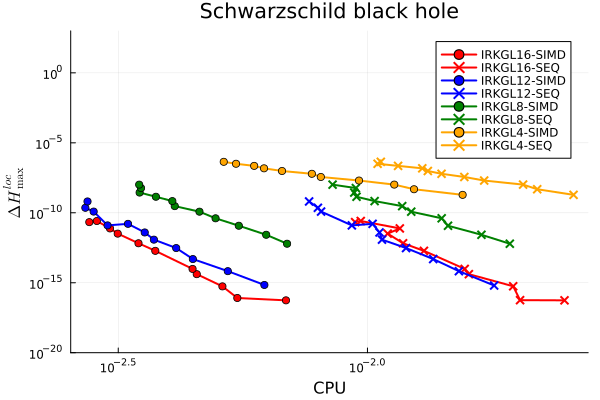

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


In [22]:
plot(pl1) 

In [23]:
savefig("./figures/Fig2.pdf")

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


"/home/mikel/Nextcloud/Gure taldea (Ehu box)/IRKGL-2025/6-Splitting-metodoak/Splitting Solvers Implementation/Experiments_Article3/5_3_1-Atala/figures/Fig2.pdf"

<a href="#top">Back to the top</a>

## Splitting integrations

In [24]:
u0v2, parmsv2 = InitialSchwarzschildv2()
HAMV2=Ham_Schwarzschildv2

flows=[flowH1Schwarzschildv2!, flowH2Schwarzschildv2!, flowH3Schwarzschildv2!]
prob=SplittingProblem(flows, u0v2, tspan, parmsv2);

@show HAMV2(u0v2,parmsv2)

HAMV2(u0v2, parmsv2) = -0.5


-0.5

### Composition methods

In [25]:
ddt0_split=collect(0.5:0.25:5)
nruns=100

s=1; r=2
alg=Splitting_alg(r=r, rkn=false)
sols_split_r2=run_many_Splitting(s, alg, prob, ddt0_split, HAMV2, nruns=nruns)
#fig=plots_Splitting("Split r=2", alg, prob, HAMV2, sols_split_r2)
#display(fig)
#
s=5; r=4
alg=Splitting_alg(r=r, rkn=false)
sols_split_r4=run_many_Splitting(s, alg, prob, s*ddt0_split, HAMV2, nruns=nruns)
#
s=13; r=6
alg=Splitting_alg(r=r, rkn=false)
sols_split_r6=run_many_Splitting(s, alg, prob, s*ddt0_split, HAMV2, nruns=nruns)
#
s=21; r=8
alg=Splitting_alg(r=r, rkn=false)
sols_split_r8=run_many_Splitting(s, alg, prob, s*ddt0_split, HAMV2, nruns=nruns)
#
s=35; r=10
alg=Splitting_alg(r=r, rkn=false)
sols_split_r10=run_many_Splitting(s, alg, prob, s*ddt0_split, HAMV2, nruns=nruns);

,0.5,0.75,1.0,1.25,1.5,1.75,2.0,2.25,2.5,2.75,3.0,3.25,3.5,3.75,4.0,4.25,4.5,4.75,5.0,2.5,3.75,5.0,6.25,7.5,8.75,10.0,11.25,12.5,13.75,15.0,16.25,17.5,18.75,20.0,21.25,22.5,23.75,25.0,6.5,9.75,13.0,16.25,19.5,22.75,26.0,29.25,32.5,35.75,39.0,42.25,45.5,48.75,52.0,55.25,58.5,61.75,65.0,10.5,15.75,21.0,26.25,31.5,36.75,42.0,47.25,52.5,57.75,63.0,68.25,73.5,78.75,84.0,89.25,94.5,99.75,105.0,17.5,26.25,35.0,43.75,52.5,61.25,70.0,78.75,87.5,96.25,105.0,113.75,122.5,131.25,140.0,148.75,157.5,166.25,175.0

In [26]:
[sols_split_r2.MaxΔHlocal sols_split_r4.MaxΔHlocal sols_split_r6.MaxΔHlocal sols_split_r8.MaxΔHlocal sols_split_r10.MaxΔHlocal] 

19×5 Matrix{Float64}:
 1.56152e-7   2.09048e-8   6.10109e-9       2.77416e-9      2.71707e-9
 5.27058e-7   1.56947e-7   9.73661e-8       9.11773e-8      3.94287e-7
 1.24832e-6   6.60741e-7   5.83146e-7       6.28987e-7      3.49021e-6
 2.43536e-6   2.00476e-6   3.28803e-6       6.15133e-6      3.83621e-5
 4.19908e-6   4.40285e-6   1.11601e-5       3.09664e-5      0.000193561
 6.69016e-6   9.6589e-6    2.96438e-5       0.000104794     0.000492477
 9.97831e-6   1.97317e-5   6.25243e-5       0.000241976     0.00112747
 1.42087e-5   3.6536e-5    0.000153804      0.000707009     0.00232425
 1.94308e-5   5.93525e-5   0.000241718      0.001347        0.0048753
 2.59492e-5   6.33444e-5   0.000497049      0.000601661     0.0132599
 3.36248e-5   0.000135963  0.00063736       0.00450118      0.00892747
 4.20191e-5   0.000187801  0.00133471       0.00559939      0.0107091
 5.34291e-5   0.000208591  0.00162855       0.00480148      0.0111828
 6.39019e-5   0.000398499  0.00233657       0.405651     

<a href="#top">Back to the top</a>

## Benchmarks diagrams

### Work-precison diagrams

In [29]:
sols2plot=[sols_irk16_simd, sols_irk16_seq, sols_irk16_hyb,
           sols_split_r2, sols_split_r4, sols_split_r6, sols_split_r8, sols_split_r10]

labels2plot=["IRKGL16-SIMD", "IRKGL16-SEQ", "IRKGL16-HYBR",
              "Strang(r=2)", "SUZ90(r=4)", "SS05(r=6)", "SS05(r=8)", "SS05(r=10)"] 

colors2plot=[:red, :blue, :green, :orange, :purple, :cyan, :magenta, :teal];

In [30]:
index0=4   # IRKGL16: h=16, index0=4 (exact solution)
idx=10     # IRKGL16: index1=10 optimum step-size

index=[idx]
compute_index_ge_cpu!(index, sols_irk16_simd.cpus[idx], sols2plot[2:end])

for i in 1:length(index)
    
    k=index[i]
    println(k, " , ", labels2plot[i], " , ", sols2plot[i].dts[k], " , ", sols2plot[i].cpus[k])
    
end


10 , IRKGL16-SIMD , 28.0 , 0.0028646730000000003
11 , IRKGL16-SEQ , 30.0 , 0.009446498080000003
11 , IRKGL16-HYBR , 30.0 , 0.0037123357899999983
16 , Strang(r=2) , 4.25 , 0.002965603329999999
12 , SUZ90(r=4) , 16.25 , 0.0029908512800000003
11 , SS05(r=6) , 39.0 , 0.003222018769999999
12 , SS05(r=8) , 68.25 , 0.0030059787799999993
12 , SS05(r=10) , 113.75 , 0.00287238235


┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


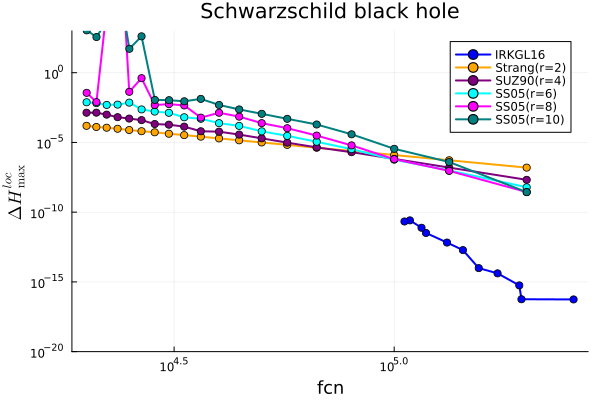

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


In [31]:
yrange=(1e-20, 1e3)
xrange=(1,50)

fcn=8*(sols_irk16_seq.iters)

sols=sols_irk16_seq

pl3=plot( fcn , sols.MaxΔHlocal, scale=:log10,
         markershape=:circle, lw=2,
         ylimits=yrange,    
         label="IRKGL16", color=colors2plot[2],
         title="Schwarzschild black hole", 
         xlabel="fcn", ylabel=L"\Delta H^{loc}_{\mathrm{max}}",
         guidefont=font(12), labelsize=10)


for i in 4:length(sols2plot)
       
   sols=sols2plot[i]
    
   if occursin("rkn", labels2plot[i])
       plot!(pl3, sols.nflowsH3 , sols.MaxΔHlocal, 
       markershape=:xcross, lw=2, ls=:dash,
       label=labels2plot[i], color=colors2plot[i],
       scale=:log10)
        
   else 
       plot!(pl3, sols.nflowsH3 , sols.MaxΔHlocal, 
             markershape=:circle, lw=2,
             label=labels2plot[i], color=colors2plot[i],
             scale=:log10)
   end

end

display(pl3)

In [32]:
#savefig("./figures/FigXX.pdf")

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


"/home/mikel/Nextcloud/Gure taldea (Ehu box)/IRKGL-2025/6-Splitting-metodoak/Splitting Solvers Implementation/Experiments_Article3/5_3_1-Atala/figures/FigXX.pdf"

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


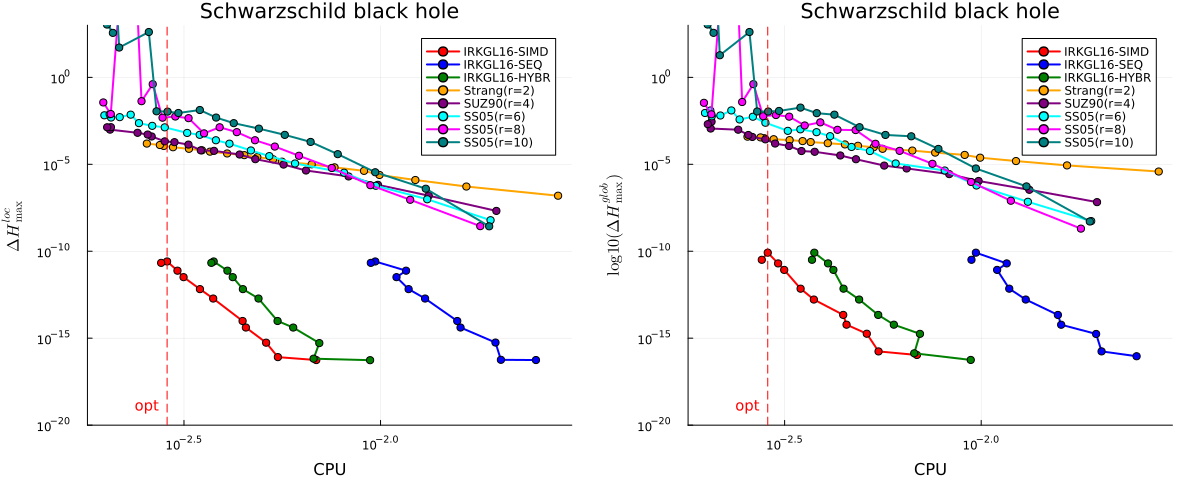

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


In [33]:
yrange=(1e-20, 1e3)

xrange=(1,50)

sols=sols_irk16_simd
pl1=plot( sols.cpus , sols.MaxΔHlocal, scale=:log10,
          markershape=:circle, lw=2,
          ylimits=yrange, 
          label=labels2plot[1], color=colors2plot[1],
          title="Schwarzschild black hole", xlabel="CPU", ylabel=L"\Delta H^{loc}_{\mathrm{max}}")

for i in 2:length(sols2plot)
    
    sols=sols2plot[i]
    
    plot!(pl1, sols.cpus , sols.MaxΔHlocal, 
          markershape=:circle, lw=2,
         label=labels2plot[i], color=colors2plot[i],
         scale=:log10)
    
end

vline!(pl1, [sols_irk16_simd.cpus[index[1]]], line=:dash, label="", color=:red)
annotate!((sols_irk16_simd.cpus[index[1]]+0.12, 0.05), text("opt", :red, 10, :center))

#########################################

sols=sols_irk16_simd
pl2=plot( sols.cpus , sols.MaxΔHglobal, scale=:log10,
         markershape=:circle, lw=2,
         ylimits=yrange, 
         label=labels2plot[1], color=colors2plot[1],
         title="Schwarzschild black hole", xlabel="CPU", ylabel=L"\log10(\Delta H^{glob}_{\mathrm{max}})")


for i in 2:length(sols2plot)
    
    sols=sols2plot[i]
    
    plot!(pl2, sols.cpus , sols.MaxΔHglobal, 
          markershape=:circle, lw=2,
          label=labels2plot[i], color=colors2plot[i],
          scale=:log10)

end

vline!(pl2, [sols_irk16_simd.cpus[index[1]]], line=:dash, label="", color=:red)
annotate!((sols_irk16_simd.cpus[index[1]]+0.12, 0.05), text("opt", :red, 10, :center))


plot(pl1, pl2, layout=(1,2), size=(1200,500), 
    bottom_margin=10Plots.mm,
    left_margin=5Plots.mm, right_margin=5Plots.mm)

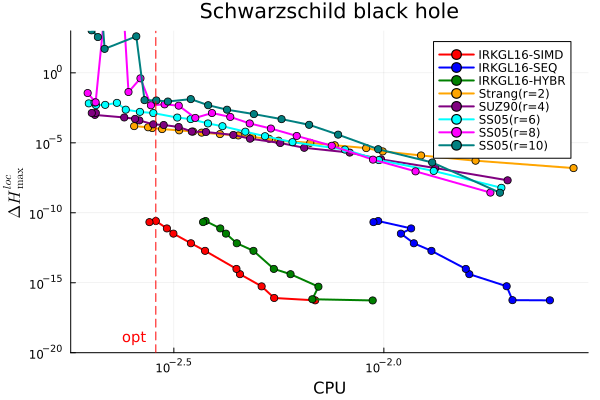

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


In [34]:
plot(pl1) #plot(pl2)

In [35]:
savefig("./figures/Fig7.pdf")

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


"/home/mikel/Nextcloud/Gure taldea (Ehu box)/IRKGL-2025/6-Splitting-metodoak/Splitting Solvers Implementation/Experiments_Article3/5_3_1-Atala/figures/Fig7.pdf"

<a href="#top">Back to the top</a>

### Error in Energy

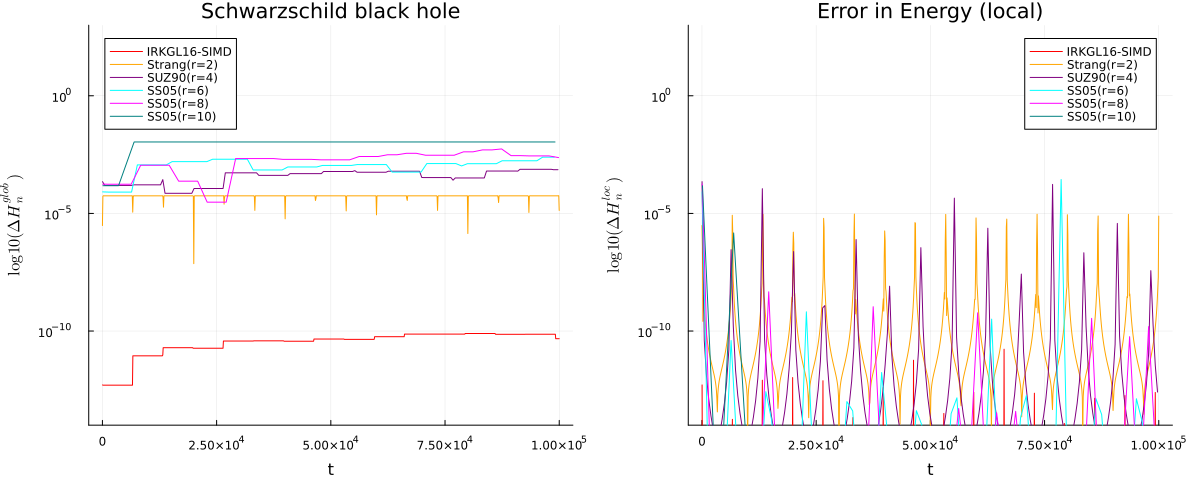

In [36]:
yrange=(1e-14, 1e3)


onesols2plot=[sols_irk16_simd.sols[index[1]], sols_split_r2.sols[index[3]], sols_split_r4.sols[index[4]],
              sols_split_r6.sols[index[5]],   sols_split_r8.sols[index[6]], sols_split_r10.sols[index[7]]]

labels2plot_=["IRKGL16-SIMD", 
              "Strang(r=2)", "SUZ90(r=4)", "SS05(r=6)", "SS05(r=8)", "SS05(r=10)", 
              "BM02(rkn6)", "BCE22(rkn8)" ]

colors2plot_ = [:red, :orange, :purple, :cyan, :magenta, :teal, :gold, :gray]

H0=HAM(BigFloat.(u0),BigFloat.(parms))

H = [HAM(BigFloat.(u),BigFloat.(parms)) for u in sols_irk16_simd.sols[index[1]].u]
ΔH0 = @. Float64(abs(H/H0-1))
ΔH0loc = @. Float64(abs((H[2:end] / H[1:end-1]) - 1))

m0 = max(1,div(Int64(ceil((tF-t0)/ddt0_irk16[index[1]])),1000))

pl3=plot(sols_irk16_simd.sols[index[1]].t[2:m0:end], abs.(ΔH0[2:m0:end]),
        ylimits=yrange,
        xlabel="t", ylabel=L"\log10(\Delta H^{glob}_n)",title="Schwarzschild black hole",
        label=labels2plot_[1],color=colors2plot_[1],
        yscale=:log10, legend=:topleft)

pl4=plot(sols_irk16_simd.sols[index[1]].t[2:m0:end], abs.(ΔH0loc[1:m0:end]),
        ylimits=yrange,
        xlabel="t", ylabel=L"\log10(\Delta H^{loc}_n)",title="Error in Energy (local)",
        label=labels2plot_[1],color=colors2plot_[1],
        yscale=:log10)

# splitting

H0=HAMV2(BigFloat.(u0v2),BigFloat.(parmsv2))
for k in 2:length(onesols2plot)
    m0 = max(1,div(Int64(ceil((tF-t0)/ddt0_split[index[k+1]])),1000))
    solk=onesols2plot[k]
    labelk=labels2plot_[k]
    colork=colors2plot_[k]
    H = [HAMV2(BigFloat.(u),BigFloat.(parmsv2)) for u in solk.u]
    ΔH0 = @. Float64(abs(H/H0-1))
    ΔH0loc = @. Float64(abs((H[2:end] / H[1:end-1]) - 1))
    plot!(pl3, solk.t[2:m0:end], abs.(ΔH0[2:m0:end]), yscale=:log10, label=labelk, color=colork)
    plot!(pl4, solk.t[2:m0:end], abs.(ΔH0loc[1:m0:end]), yscale=:log10, label=labelk, color=colork)
end


fig=plot(pl3, pl4, layout=(1,2), size=(1200,500), 
    bottom_margin=10Plots.mm,
    left_margin=5Plots.mm, right_margin=5Plots.mm)

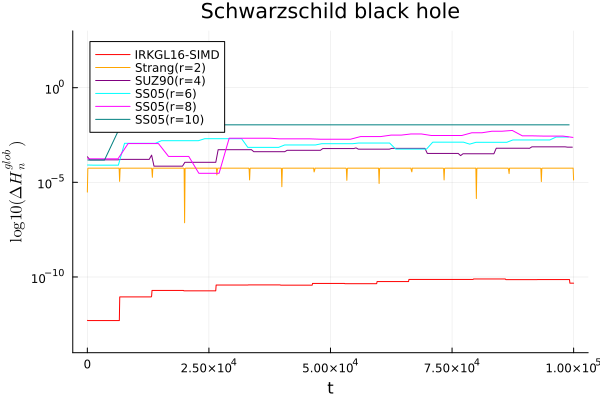

In [37]:
plot(pl3)

In [38]:
savefig("./figures/Fig8.pdf")

"/home/mikel/Nextcloud/Gure taldea (Ehu box)/IRKGL-2025/6-Splitting-metodoak/Splitting Solvers Implementation/Experiments_Article3/5_3_1-Atala/figures/Fig8.pdf"

<a href="#top">Back to the top</a>

### Error in Solution

In [39]:
errors2plot=[sols_irk16_simd.sols[index[1]], sols_split_r2.sols[index[3]], sols_split_r4.sols[index[4]],
              sols_split_r6.sols[index[5]],   sols_split_r8.sols[index[6]], sols_split_r10.sols[index[7]]]

ddt02plot=[sols_irk16_simd.dts[index[1]], sols_split_r2.dts[index[3]], sols_split_r4.dts[index[4]],
           sols_split_r6.dts[index[5]],   sols_split_r8.dts[index[6]], sols_split_r10.dts[index[7]]]

labels2plot_er=["IRKGL16-SIMD",  
              "Strang(r=2)", "SUZ90(r=4)", "SS05(r=6)", "SS05(r=8)", "SS05(r=10)"] 

#labels2plot=["IRKGL16-SIMD", "IRKGL16-SEQ", "IRKGL16-HYBR",
#              "Strang(r=2)", "SUZ90(r=4)", "SS05(r=6)", "SS05(r=8)", "SS05(r=10)"] 
#colors2plot=[:red, :blue, :green, :orange, :purple, :cyan, :magenta, :teal];

colors2plot_er=[:red, :orange, :purple, :cyan, :magenta, :teal];


k=1,IRKGL16-SIMD,[112.0, 224.0, 336.0]
k=1,IRKGL16-SIMD,[112.0, 224.0, 336.0]
*****************************
k=2,Strang(r=2),[48.0, 96.0, 144.0]
k=2,Strang(r=2),[48.0, 96.0, 144.0]
*****************************
k=3,SUZ90(r=4),[1360.0, 2720.0, 4080.0]
k=3,SUZ90(r=4),[1360.0, 2720.0, 4080.0]
*****************************
k=4,SS05(r=6),[2704.0, 5408.0, 8112.0]
k=4,SS05(r=6),[2704.0, 5408.0, 8112.0]
*****************************
k=5,SS05(r=8),[1008.0, 2016.0, 3024.0]
k=5,SS05(r=8),[1008.0, 2016.0, 3024.0]
*****************************
k=6,SS05(r=10),[7280.0, 14560.0, 21840.0]
k=6,SS05(r=10),[7280.0, 14560.0, 21840.0]
*****************************


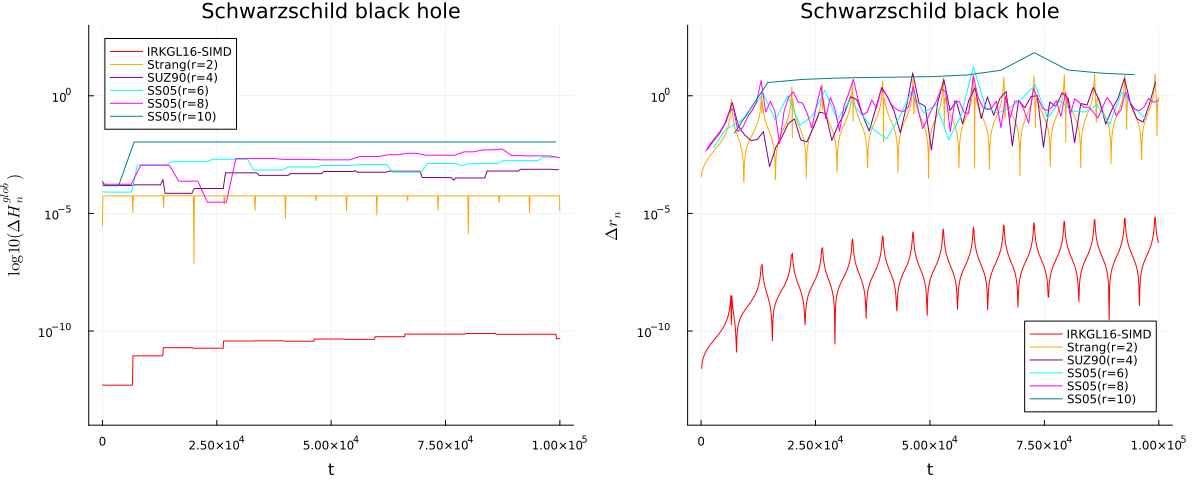

In [40]:
yrange=(1e-14, 1e3)

pe1=plot(title="Schwarzschild black hole", yscale=:log10,
         ylims=yrange,
         legend=:bottomright,
         xlabel="t", ylabel=L"\Delta r_n")

for k in 1:length(errors2plot)
    
    w=lcm_floats_vector(vcat(ddt0_irk16[index0],ddt02plot[k]))
    ii=Int64.(w./(vcat(ddt0_irk16[index0],ddt02plot[k]))).+1
    
    v0=sols_irk16_simd.sols[index0].t[ii[1]:ii[1]-1:3*ii[1]] 
    v1=errors2plot[k].t[ii[2]:ii[2]-1:3*ii[2]]
    
    println("k=", k, ",",labels2plot_er[k],",", v0 )
    println("k=", k, ",",labels2plot_er[k],",", v1 )
    println("*****************************")
    
    if k==1
        error= map((u,u1)-> abs(BigFloat(u[1])/BigFloat(u1[1])-1),
                errors2plot[k].u[ii[2]:ii[2]-1:end], sols_irk16_simd.sols[index0].u[ii[1]:ii[1]-1:end])
    
    else
       # r=sqrt(x^2+y^2) for splitting methods
       error= map((u,u1)-> abs(sqrt(BigFloat(u[1])^2+BigFloat(u[2])^2)/BigFloat(u1[1])-1),
                errors2plot[k].u[ii[2]:ii[2]-1:end], sols_irk16_simd.sols[index0].u[ii[1]:ii[1]-1:end])
    end 
    
    tt=sols_irk16_simd.sols[index0].t[ii[1]:ii[1]-1:end]
    
    plot!(pe1, tt, error,
          label=labels2plot_er[k],color=colors2plot_er[k])
    
end

fig=plot(pl3, pe1, layout=(1,2), size=(1200,500), 
    bottom_margin=10Plots.mm,
    left_margin=5Plots.mm, right_margin=5Plots.mm)

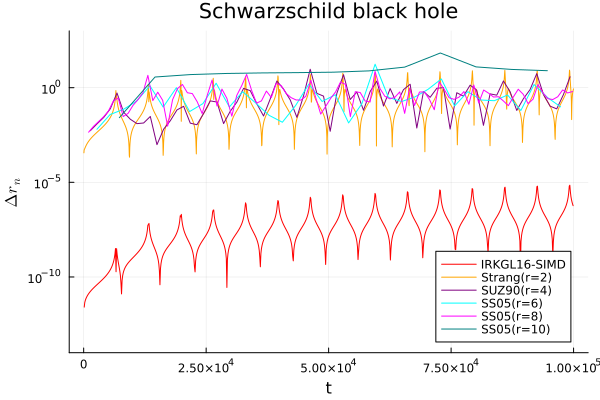

In [41]:
plot(pe1)

In [42]:
savefig("./figures/Fig9.pdf")

"/home/mikel/Nextcloud/Gure taldea (Ehu box)/IRKGL-2025/6-Splitting-metodoak/Splitting Solvers Implementation/Experiments_Article3/5_3_1-Atala/figures/Fig9.pdf"